# Assignment 2

Written by Kira Damo

Due February 16th, 2026

# Part 1

## Question 1a

In [1]:
#importing necessary modules for assignment

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
#reading all the txt files as a table
#header set to none to include all rows per the readme.txt
modified_train = pd.read_table('/Users/kiradamo/Documents/DSC 478/newsgroups/trainMatrixModified.txt', header=None)
modified_test = pd.read_table('/Users/kiradamo/Documents/DSC 478/newsgroups/testMatrixModified.txt', header=None)
train_labels = pd.read_table('/Users/kiradamo/Documents/DSC 478/newsgroups/trainClasses.txt', header=None, index_col=0)
test_labels = pd.read_table('/Users/kiradamo/Documents/DSC 478/newsgroups/testClasses.txt', header=None, index_col=0)
modified_terms = pd.read_table('/Users/kiradamo/Documents/DSC 478/newsgroups/modifiedterms.txt', header=None)

To verify the rows and columns of each matrix align with the readme.txt, I'm printing the shape. There are 5500 terms and 800 documents.

In [3]:
modified_train.shape

(5500, 800)

In [4]:
modified_test.shape

(5500, 200)

In [5]:
train_labels.shape

(800, 1)

In [6]:
test_labels.shape

(200, 1)

In [7]:
modified_terms.shape

(5500, 1)

In [8]:
train_frequencies = modified_train.sum(axis=1).sort_values(ascending= False)
#top 20 terms -> index and frequencies
train_frequencies[0:20]

3       959.0
225     720.0
136     680.0
1682    578.0
115     545.0
30      483.0
107     470.0
84      429.0
192     401.0
82      378.0
690     370.0
25      329.0
45      326.0
36      325.0
451     323.0
187     319.0
9       318.0
640     311.0
184     302.0
106     300.0
dtype: float64

In [9]:
#showing the terms that are the top 20
terms = modified_terms.iloc[train_frequencies.index]
terms[0:20]

,0
3,subject
225,window
136,game
1682,do
115,get
30,write
107,team
84,on
192,plai
82,go


**Plot of training data frequencies:**

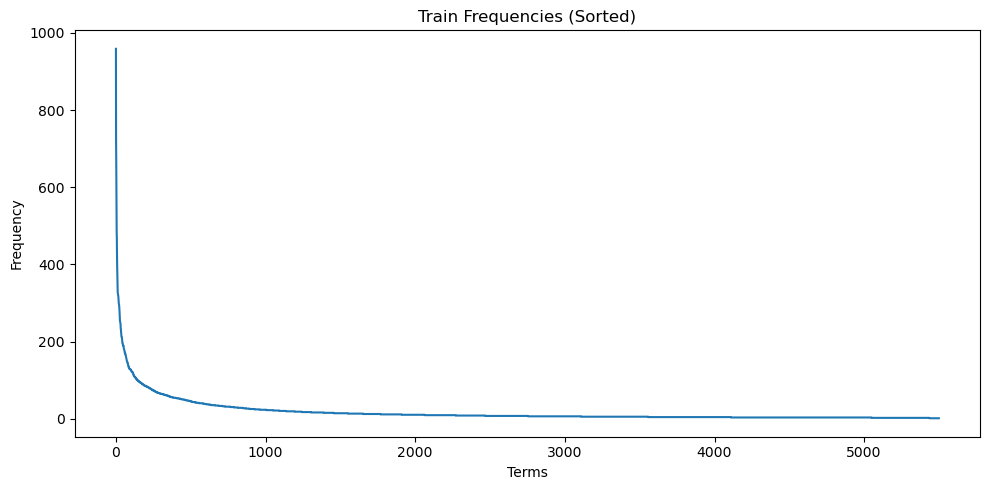

In [10]:
#keeping the terms as their index numbers rather than their actual terms
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_frequencies)), train_frequencies.values)
plt.xlabel("Terms")
plt.ylabel("Frequency")
plt.title("Train Frequencies (Sorted)")
plt.tight_layout()
plt.show()

The distribution indicates that common short words like do, get, or on occur more frequently than document-subject-specific words like hockei or file.

In [11]:
train_labels

,1
0,
0,0
1,1
2,0
3,1
4,0
...,...
795,0
796,1
797,1


In [12]:
np.array(train_labels).flatten()

array([0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,

In [13]:
test_labels

,1
0,
0,1
1,0
2,0
3,1
4,1
...,...
195,1
196,1
197,0


In [14]:
np.array(test_labels).flatten()

array([1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1])

## Question 1B - KNN Classifier

To find the nearest neighbors, the matrices will all be transposed to have the documents in rows and the terms in columns.

In [15]:
mod_train = modified_train.T
mod_train.shape

(800, 5500)

In [16]:
mod_test = modified_test.T
mod_test.shape

(200, 5500)

finds the k-nearest neighbor. The function takes x (a row of data), D (an input array) and K (the number of nearest neighbors), and the choice of 0 or 1. if Eulidean, measure = 0 and if cosine, measure = 1.

In [17]:
def knn_search(x, D, K, measure):
    """ find K nearest neighbors of an instance x among the instances in D """
    if measure == 0:
        # euclidean distances from the other points
        dists = np.sqrt(((D - x)**2).sum(axis=1))
    elif measure == 1:
        # first find the vector norm for each instance in D as wel as the norm for vector x
        D_norm = np.array([np.linalg.norm(D[i]) for i in range(len(D))])
        x_norm = np.linalg.norm(x)
        # Compute Cosine: divide the dot product o x and each instance in D by the product of the two norms
        sims = np.dot(D,x)/(D_norm * x_norm)
        # The distance measure will be the inverse of Cosine similarity
        dists = 1-sims
    idx = np.argsort(dists) # sorting
    # return the indexes of K nearest neighbors
    return idx[:K], dists

In [18]:
def knn_classify(x, D, K, labels, measure):
    from collections import Counter
    neigh_idx, distances = knn_search(x, D, K, measure)
    neigh_labels = labels[neigh_idx]
    count = Counter(neigh_labels)
    #print("Labels for top ", K, "neighbors: ", count)
    predicted_label = count.most_common(1)[0][0]
    return neigh_idx, predicted_label

In [19]:
DTM_train = np.array(mod_train)
DTM_test = np.array(mod_test)
train_lab_array = np.array(train_labels).flatten()
test_lab_array = np.array(test_labels).flatten()

Running the classifier on the first two instances using cosine similarity and euclidian distance:

In [20]:
#First instance of test data with cosine similarity
top_K_neighbors, predicted_class = knn_classify(DTM_test[0], DTM_train, 10, train_lab_array, 1)
print(f'The indices of K Nearest Neighbors are: {top_K_neighbors} \nThe predicted class is: {predicted_class}')

The indices of K Nearest Neighbors are: [685 628 667 152 427 194 416 710 113 419] 
The predicted class is: 1


In [21]:
#First instance of test data with euclidian distance
top_K_neighbors, predicted_class = knn_classify(DTM_test[0], DTM_train, 10, train_lab_array, 0)
print(f'The indices of K Nearest Neighbors are: {top_K_neighbors} \nThe predicted class is: {predicted_class}')

The indices of K Nearest Neighbors are: [685 628 703 266 510 224 798 343 126 757] 
The predicted class is: 1


In [22]:
#Second instance of test data with cosine similarity
top_K_neighbors, predicted_class = knn_classify(DTM_test[1], DTM_train, 10, train_lab_array, 1)
print(f'The indices of K Nearest Neighbors are: {top_K_neighbors} \nThe predicted class is: {predicted_class}')

The indices of K Nearest Neighbors are: [382 775 163 587 550 127 485 651 767 458] 
The predicted class is: 0


In [23]:
#Second instance of test data with Euclidian distance
top_K_neighbors, predicted_class = knn_classify(DTM_test[1], DTM_train, 10, train_lab_array, 0)
print(f'The indices of K Nearest Neighbors are: {top_K_neighbors} \nThe predicted class is: {predicted_class}')

The indices of K Nearest Neighbors are: [798 554 757 224  38 119 711 398 608 551] 
The predicted class is: 0


## Question 1C - KNN Evaluation

In [24]:
def knn_evaluate(test, test_labs, train, train_labs, K, measure):
    # Inputs:
    # test: an array or list of test instances
    # test_labs: an array or list of class labels for the corresponding test instances in test
    # train: the training instances
    # train_labs: class labels for the corresponding training instances in train
    # K: number of neighbors
    # measure: 0 = Euclidean distance; 1 = Cosine distance

    T=0 # no. of correctly classified instances
    F=0 # no. of incorrectly classified instances
    for i in range(len(test)):
        actual=test_labs[i]
        top_K_neighbors, predicted = knn_classify(test[i], train, K, train_labs, measure)
        if actual == predicted:
            T += 1       
        else:
            F += 1     
    accuracy = float(T)/float(T+F) 
    return accuracy

In [25]:
accuracy = knn_evaluate(mod_test, test_lab_array, mod_train, train_lab_array, 10, 0)
print(f'Classification Accuracy: {accuracy}')

Classification Accuracy: 0.55


## Question 1D - KNN Evaluation Plot

To create the plot, I am initializing two empty lists that will be populated with accuracies from the evaluate function.

In [26]:
#initializing empty list
Euclid = []
Cosine = []

In [27]:
for K in range(5, 100, 5):
    Euclid.append(knn_evaluate(DTM_test, test_lab_array, DTM_train, train_lab_array, K, 0))

In [28]:
for K in range(5, 100, 5):
    Cosine.append(knn_evaluate(DTM_test, test_lab_array, DTM_train, train_lab_array, K, 1))

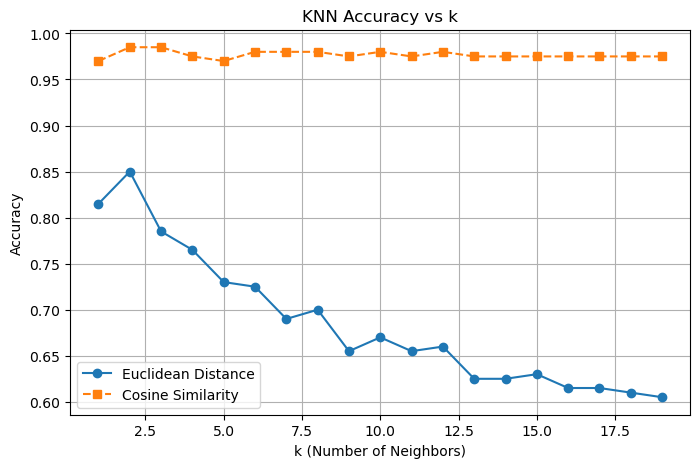

In [29]:
#k values from 1 to 19
k_values = np.arange(1, 20)

#Convert to numpy arrays
euclid_acc = np.array(Euclid)
cosine_acc = np.array(Cosine)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_values, euclid_acc, marker='o', label='Euclidean Distance')
plt.plot(k_values, cosine_acc, marker='s', linestyle='--', label='Cosine Similarity')

# Labels and title
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')

# Extras
plt.legend()
plt.grid(True)

plt.show()

## Question 1E TFxIDF

TFxIDF on the training data:

Creating a copy of the training and testing data:

In [30]:
mod_train_tf = mod_train.copy()
mod_test_tf = mod_test.copy()

Finding the term frequency of documents in the training data and the number of documents

In [31]:
df_train = (mod_train > 0).sum(axis=0)
N_docs = mod_train.shape[0]
#inverse document frequency
mod_train_idf = np.log(N_docs / df_train)

Multiplying the term frequency and the inverse document frequency

In [32]:
mod_train_tfidf = mod_train_tf.mul(mod_train_idf, axis=1)
mod_test_tfidf = mod_test_tf.mul(mod_train_idf, axis=1)
 
mod_train_tfidf

,0,1,2,3,4,5,6,7,8,9,...,5490,5491,5492,5493,5494,5495,5496,5497,5498,5499
0,5.545177,9.477403,8.764053,0.0,16.019844,19.313255,5.466736,22.675713,6.77755,5.565228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.0,2.002481,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,5.668928,0.00000,1.391307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5.545177,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.545177,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
796,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
797,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
798,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Question 1F Rocchio Method

Initializing all training and test data to be numpy arrays

In [33]:
X_train_np = mod_train.values.astype(float)
X_test_np  = mod_test.values.astype(float)
y_train_np = train_labels.values.ravel()
y_test_np  = test_labels.values.ravel()

Since KNN search is not necessary, I created a cosine similarity function (also used in assignment 2 notes)

In [34]:
def cosSim(a, b):
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    
    if a_norm == 0 or b_norm == 0:
        return 0
    
    return np.dot(a, b) / (a_norm * b_norm)

Training the data. Train variable is x-variable training data and labels is y-variable training data.

In [35]:
def rocchio_train(train, labels):
    #X_train, y_train
    classes = np.unique(labels)
    n_terms = train.shape[1]
    prototypes = {}
    
    for c in classes:
        #creates a numpy array of zeros that is the length of the number of terms
        prototypes[c] = np.zeros(n_terms)

    for c in classes:
        # select all rows (documents) for this class
        class_docs = train[labels == c, :]
        # prototype = mean of class documents
        prototypes[c] = class_docs.mean(axis=0)

    return prototypes

In [36]:
def rocchio_classifier(prototypes, instance):
    m = -2
    predicted_label = None
    similarities = {}
    for c, prototype in prototypes.items():
        s = cosSim(instance, prototype)
        similarities[c] = s
        if s > m:
            m = s
            predicted_label = c
            
    return predicted_label, similarities

In [37]:
def rocchio_evaluate(test, test_lab, prototype):
    correct = 0
    n_docs = test.shape[0]
    
    for i in range(n_docs):
        doc = test[i,:]
        pred_class, _ = rocchio_classifier(prototype, doc)
        
        if pred_class == test_lab[i]:
            correct += 1
        
        doc = test[i, :]
        pred_class, similarities = rocchio_classifier(prototype, doc)
        #print statement that shows the predictions and similarities to each class
        print(f'Document {i+1}: True class = {test_lab[i]}, Predicted = {pred_class}')
        for c, s in similarities.items():
            print(f'Similarity to class {c}: {s:.4f}')

    accuracy = correct / n_docs
    return accuracy

In [38]:
prototypes = rocchio_train(X_train_np, y_train_np)
accuracy = rocchio_evaluate(X_test_np, y_test_np, prototypes)

Document 1: True class = 1, Predicted = 1
Similarity to class 0: 0.1584
Similarity to class 1: 0.4413
Document 2: True class = 0, Predicted = 0
Similarity to class 0: 0.2873
Similarity to class 1: 0.0961
Document 3: True class = 0, Predicted = 1
Similarity to class 0: 0.1386
Similarity to class 1: 0.1569
Document 4: True class = 1, Predicted = 1
Similarity to class 0: 0.0494
Similarity to class 1: 0.1667
Document 5: True class = 1, Predicted = 1
Similarity to class 0: 0.1056
Similarity to class 1: 0.3329
Document 6: True class = 0, Predicted = 0
Similarity to class 0: 0.2976
Similarity to class 1: 0.0952
Document 7: True class = 1, Predicted = 1
Similarity to class 0: 0.0597
Similarity to class 1: 0.1823
Document 8: True class = 1, Predicted = 1
Similarity to class 0: 0.1166
Similarity to class 1: 0.3837
Document 9: True class = 0, Predicted = 0
Similarity to class 0: 0.2307
Similarity to class 1: 0.1243
Document 10: True class = 1, Predicted = 1
Similarity to class 0: 0.0907
Similarit

In [39]:
print(f"Rocchio classifier Accuracy: {accuracy:.4f}")

Rocchio classifier Accuracy: 0.9750


Unlike KNN, Rocchio treats each class as a centroid and finds cosine similarity. KNN treats zeros differently because the distance is calculated between each item rather than one centroid to another.

## Question 1G Scikit-Learn Nearest Centroid

In [40]:
from sklearn.neighbors import NearestCentroid

The parameters of NearestCentroid are metric='euclidean', *, shrink_threshold=None, and priors='uniform'.

In [41]:
NC = NearestCentroid(metric='euclidean')
NC.fit(X_train_np, y_train_np)

,metric,'euclidean'
,shrink_threshold,None
,priors,'uniform'


In [42]:
y_pred = NC.predict(X_test_np)
accuracy = np.mean(y_pred == y_test_np)
print(f"Nearest Centroid (Euclidean) accuracy: {accuracy:.4f}")

Nearest Centroid (Euclidean) accuracy: 0.9400


Since nearest centroid uses Euclidean accuracy, normalizing the data to be between 0 and 1 will allow a better comparison between models since Rocchio method utilizes cosine similarity. 

In [43]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [44]:
X_train_norm = scaler.fit_transform(X_train_np)
X_test_norm = scaler.transform(X_test_np)

In [45]:
NC.fit(X_train_norm, y_train_np)
y_pred = NC.predict(X_test_norm)

In [46]:
accuracy = np.mean(y_pred == y_test_np)
print(f"Nearest Centroid (MinMax-scaled) accuracy: {accuracy:.4f}")

Nearest Centroid (MinMax-scaled) accuracy: 0.8500


The accuracy of the Nearest centroid model is 71.46% which is much more accurate than the Rocchio classification results. Since nearest centroid uses euclidean distance rather than cosine, the magnitudes may make results vary. Normalized data disregards the length of magnitude which in this case does not work in the data's favor.

# Part 2

## Question 2A

In [47]:
#not necessary but I'm re-importing the modules as a distinction for this section
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [48]:
#loading the data
adultDF = pd.read_csv('/Users/kiradamo/Documents/DSC 478/adult-modified-01-25-2026.csv')

In [49]:
#Returning the first 10 values to see the data
adultDF.head(10)

,age,workclass,education-num,marital-status,occupation,race,sex,hours-per-week,income
0,22.0,Self-employed,9,Married,Craft-repair,White,Male,60,<=50K
1,52.0,Private,13,Married,Machine-op-inspct,White,Male,40,>50K
2,23.0,Private,2,Married,Machine-op-inspct,Amer-Indian-Eskimo,Female,35,<=50K
3,41.0,Private,9,Married,Craft-repair,White,Male,72,>50K
4,65.0,Self-employed,10,Married,Exec-managerial,White,Male,40,<=50K
5,49.0,Private,4,Married,Machine-op-inspct,White,Female,40,<=50K
6,39.0,Public,14,Divorced,Prof-specialty,Black,Male,40,<=50K
7,46.0,Private,9,Divorced,Other-service,White,Male,25,<=50K
8,28.0,Private,7,Never-married,Adm-clerical,White,Male,40,<=50K
9,31.0,Private,14,Married,Tech-support,White,Male,40,>50K


In [50]:
adultDF_dummies = pd.get_dummies(adultDF)
adultDF_dummies

,age,education-num,hours-per-week,workclass_Private,workclass_Public,workclass_Self-employed,workclass_Without-pay,marital-status_Divorced,marital-status_Married,marital-status_Married-spouse-absent,...,occupation_Transport-moving,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male,income_<=50K,income_>50K
0,22.0,9,60,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
1,52.0,13,40,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True
2,23.0,2,35,True,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,True,False
3,41.0,9,72,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True
4,65.0,10,40,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,50.0,9,48,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,True,True,False
9596,59.0,9,40,True,False,False,False,True,False,False,...,False,False,True,False,False,False,False,True,True,False
9597,36.0,13,40,True,False,False,False,False,True,False,...,False,False,False,False,False,True,True,False,False,True
9598,23.0,11,36,True,False,False,False,False,False,False,...,False,False,False,False,False,True,True,False,True,False


In [51]:
y = adultDF_dummies['income_>50K']
X = adultDF_dummies.drop(['income_>50K','income_<=50K'], axis=1)

In [52]:
from sklearn.model_selection import train_test_split

In [53]:
#splitting the data into randomized testing and training sets
#y is the labels (high vs low income) and x is the other attributes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 111)

For dimension checks especially when creating functions that use matrices as paramaters:

In [54]:
print(X_train.shape)
print(y_train.shape)

(7680, 34)
(7680,)


In [55]:
print(X_test.shape)
print(y_test.shape)

(1920, 34)
(1920,)


## Question 2B 

### Part 2B i

In [56]:
from sklearn import preprocessing

In [57]:
min_max_scaler = preprocessing.MinMaxScaler()

In [58]:
X_train_norm = min_max_scaler.fit_transform(X_train)
X_test_norm = min_max_scaler.fit_transform(X_test)

Data is now normalized. 

In [59]:
X_train_norm

array([[0.46575342, 0.6       , 0.39795918, ..., 1.        , 0.        ,
        1.        ],
       [0.50684932, 0.33333333, 0.09183673, ..., 0.        , 1.        ,
        0.        ],
       [0.46575342, 0.6       , 0.5       , ..., 1.        , 0.        ,
        1.        ],
       ...,
       [0.26027397, 0.8       , 0.5       , ..., 1.        , 0.        ,
        1.        ],
       [0.52054795, 0.53333333, 0.39795918, ..., 1.        , 0.        ,
        1.        ],
       [0.23287671, 0.53333333, 0.39795918, ..., 0.        , 1.        ,
        0.        ]])

In [60]:
X_test_norm

array([[0.54794521, 0.53333333, 0.37894737, ..., 0.        , 0.        ,
        1.        ],
       [0.26027397, 0.66666667, 0.58947368, ..., 1.        , 0.        ,
        1.        ],
       [0.26027397, 0.53333333, 0.53684211, ..., 1.        , 0.        ,
        1.        ],
       ...,
       [0.24657534, 0.6       , 0.58947368, ..., 0.        , 0.        ,
        1.        ],
       [0.12328767, 0.53333333, 0.37894737, ..., 1.        , 0.        ,
        1.        ],
       [0.17808219, 0.73333333, 0.37894737, ..., 1.        , 1.        ,
        0.        ]])

In this case, the labels are True or False: (True = '>50K', False = '<=50K')

In [61]:
y_train

9398     True
6263    False
5096    False
2081     True
8271    False
        ...  
7490    False
8873    False
7443    False
4182    False
4820    False
Name: income_>50K, Length: 7680, dtype: bool

In [62]:
y_test

4735     True
6367    False
4399     True
6074    False
5660     True
        ...  
8055     True
4044     True
1447    False
1775     True
4800    False
Name: income_>50K, Length: 1920, dtype: bool

In [63]:
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

Per instructions, now implementing scikit-learn's KNN features.

In [64]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

For my own reference, these are the input parameters for K neighbors classifier:
class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

In [65]:
KNN = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
KNN

,n_neighbors,10
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [66]:
#training KNN with training data
KNN.fit(X_train_norm, y_train_np)
train_pred = KNN.predict(X_train_norm)
test_pred  = KNN.predict(X_test_norm)

In [67]:
#finding the accuracy of the training model with test values
train_accuracy = np.mean(train_pred == y_train_np)
test_accuracy  = np.mean(test_pred == y_test_np)
print(f'Training Accuracy: {train_accuracy}')
print(f'Test Accuracy: {test_accuracy}')

Training Accuracy: 0.8458333333333333
Test Accuracy: 0.8145833333333333


In [68]:
conf_matrix = confusion_matrix(y_test_np, test_pred)
print('Test Data Confusion Matrix:')
print(conf_matrix)

Test Data Confusion Matrix:
[[1324  144]
 [ 212  240]]


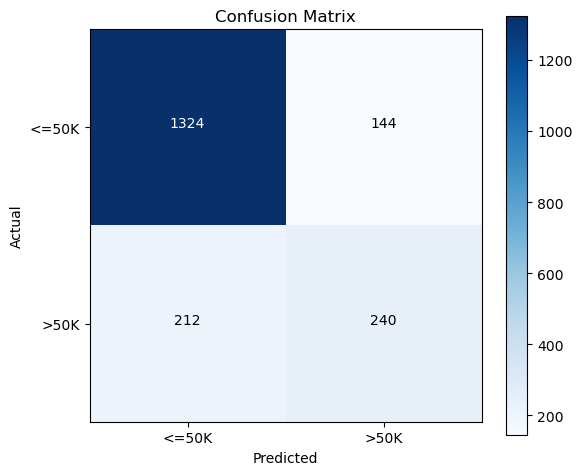

In [69]:
#using matplotlib to plot confusion matrix
labels = ['<=50K', '>50K']

plt.figure(figsize=(6,5))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

# Add numbers inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, conf_matrix[i, j],
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > conf_matrix.max()/2 else "black")

plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

Classification Report using sci-kit learn:

In [70]:
print("\nClassification Report (Test Data):")
print(classification_report(y_test_np, test_pred))


Classification Report (Test Data):
              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1468
        True       0.62      0.53      0.57       452

    accuracy                           0.81      1920
   macro avg       0.74      0.72      0.73      1920
weighted avg       0.81      0.81      0.81      1920



### Part 2B ii

Again, for my own reference, these are the input parameters for K neighbors classifier: class sklearn.neighbors.KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)

The different weights can be uniform, distance, or callable (a defined function)

In [71]:
k_values = np.arange(5, 101)
weights = ['uniform', 'distance']

In [72]:
k_values

array([  5,   6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,
        18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,
        31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
        44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
        83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
        96,  97,  98,  99, 100])

Creating accuracy dictionaries that are divided into uniform and distance weights.

In [73]:
train_accuracy = {}
test_accuracy = {}

for w in weights:
    train_accuracy[w] = []
    test_accuracy[w] = []

for w in weights:
    for k in k_values:
        KNN = KNeighborsClassifier(n_neighbors=k, weights=w, metric='euclidean')
        KNN.fit(X_train_norm, y_train_np)
        train_accuracy[w].append(KNN.score(X_train_norm, y_train_np))
        test_accuracy[w].append(KNN.score(X_test_norm, y_test_np))

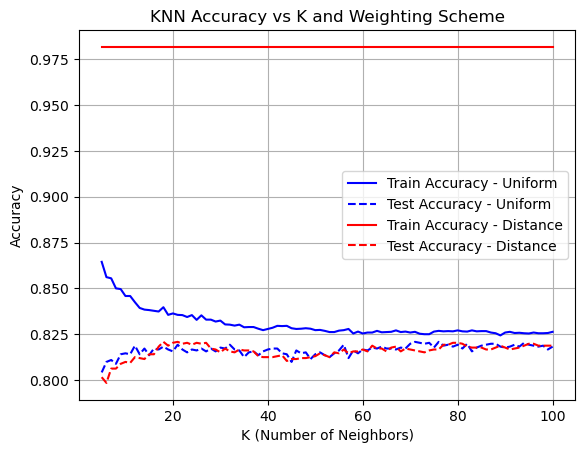

In [74]:
plt.plot(k_values, train_accuracy['uniform'], label='Train Accuracy - Uniform', color='blue', linestyle='-')
plt.plot(k_values, test_accuracy['uniform'], label='Test Accuracy - Uniform', color='blue', linestyle='--')

# Distance weighting
plt.plot(k_values, train_accuracy['distance'], label='Train Accuracy - Distance', color='red', linestyle='-')
plt.plot(k_values, test_accuracy['distance'], label='Test Accuracy - Distance', color='red', linestyle='--')

plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs K and Weighting Scheme')
plt.legend()
plt.grid(True)
plt.show()


From this plot, there we see that the model overfits the training data for the distance weight parameter.

In [75]:
#Finding best k value for testing data
best_index_test_u = np.argmax(test_accuracy['uniform'])
best_index_test_d = np.argmax(test_accuracy['distance'])
best_k_test_u = test_accuracy['uniform'][best_index_test_u]
best_k_test_d = test_accuracy['distance'][best_index_test_u]

In [76]:
#Finding best k value for training data
best_index_train_u = np.argmax(train_accuracy['uniform'])
best_index_train_d = np.argmax(train_accuracy['distance'])
best_k_train_u = test_accuracy['uniform'][best_index_train_u]
best_k_train_d = test_accuracy['distance'][best_index_train_u]

In [77]:
print(f'Accuracy of Testing Data with Uniform Weights: {best_k_test_u}, K: {best_index_test_u}')
print(f'Accuracy of Testing Data with Distance Weights: {best_k_test_d}, K: {best_index_test_d}')
print(f'Accuracy of Training Data with Uniform Weights: {best_k_train_u}, K: {best_index_train_u}')
print(f'Accuracy of Training Data with Distance Weights: {best_k_train_d}, K: {best_index_train_d}')

Accuracy of Testing Data with Uniform Weights: 0.8208333333333333, K: 66
Accuracy of Testing Data with Distance Weights: 0.8161458333333333, K: 13
Accuracy of Training Data with Uniform Weights: 0.8041666666666667, K: 0
Accuracy of Training Data with Distance Weights: 0.8015625, K: 0


Running the K Neighbors Classifier with the best K regardless of how many times the data is randomized.

In [78]:
best_knn = KNeighborsClassifier(n_neighbors=13, weights='uniform', metric='euclidean')
best_knn.fit(X_train_norm, y_train_np)
print("Training Accuracy:", best_knn.score(X_train_norm, y_train_np))
print("Test Accuracy:", best_knn.score(X_test_norm, y_test_np))

Training Accuracy: 0.8393229166666667
Test Accuracy: 0.8140625


In [79]:
best_knn = KNeighborsClassifier(n_neighbors=3, weights='distance', metric='euclidean')
best_knn.fit(X_train_norm, y_train_np)
print("Training Accuracy:", best_knn.score(X_train_norm, y_train_np))
print("Test Accuracy:", best_knn.score(X_test_norm, y_test_np))

Training Accuracy: 0.9815104166666667
Test Accuracy: 0.7859375


K cannot equal 0 because then there would be no neighboring items to report.

### Part 2B iii

In [80]:
k_values = range(5, 105, 5)

train_acc = []
test_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn.fit(X_train_norm, y_train_np)
    
    # Accuracy on training set
    train_acc.append(knn.score(X_train_norm, y_train_np))
    
    # Accuracy on test set
    test_acc.append(knn.score(X_test_norm, y_test_np))

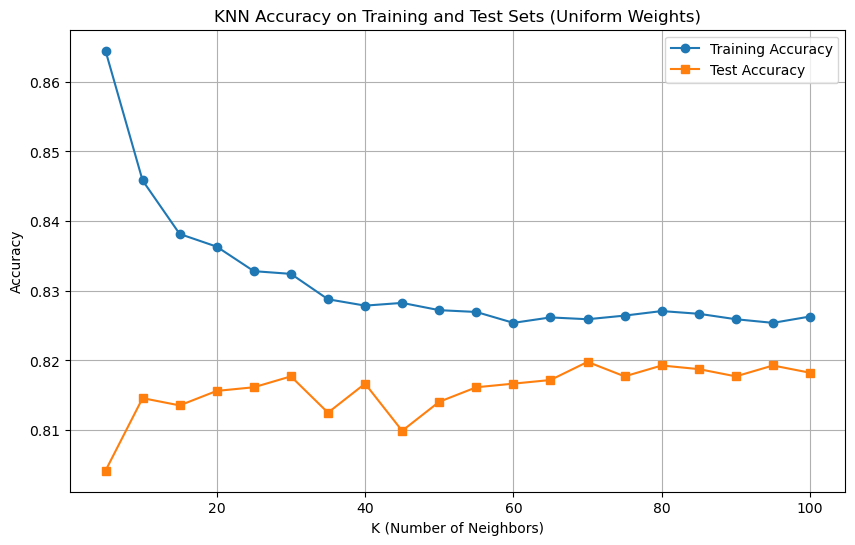

In [81]:
plt.figure(figsize=(10,6))
plt.plot(k_values, train_acc, label='Training Accuracy', marker='o')
plt.plot(k_values, test_acc, label='Test Accuracy', marker='s')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy on Training and Test Sets (Uniform Weights)')
plt.legend()
plt.grid(True)
plt.show()

The accuracy of the smaller K values (<= K=20) for the training set is the higher while the accuracy of the testing set is lower indicating that those values may suffer overfitting of the training data.

## Question 2C

Importing the modules:

In [82]:
from sklearn import neighbors, tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

Using all default parameters for the Decision Tree Classifier.

*The default parameters:*
class sklearn.tree.DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)

In [83]:
#fitting the decision tree to the training data
treeclf = tree.DecisionTreeClassifier()
treeclf = treeclf.fit(X_train, y_train)

In [84]:
#calculating the accuracy score on the test and training store
print("Accuracy on Training: ", treeclf.score(X_train, y_train))
print("Accuracy on Test: ", treeclf.score(X_test, y_test))

Accuracy on Training:  0.981640625
Accuracy on Test:  0.7703125


The decision tree with default parameters suffers overfitting of the training data since the accuracy is close to 1. This indicates low bias and high variance.

In [85]:
#classification report
y_test_pred = treeclf.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

       False       0.86      0.83      0.85      1468
        True       0.51      0.56      0.54       452

    accuracy                           0.77      1920
   macro avg       0.69      0.70      0.69      1920
weighted avg       0.78      0.77      0.77      1920



In [86]:
#confusion matrix
print(confusion_matrix(y_test, y_test_pred))

[[1224  244]
 [ 197  255]]


In [87]:
#cross validation scores
cv_scores = cross_val_score(treeclf, X_train, y_train, cv=5)
print(cv_scores)
print(f'\nOverall Accuracy on Training: {cv_scores.mean()}')

[0.76953125 0.77669271 0.7734375  0.77018229 0.77799479]

Overall Accuracy on Training: 0.7735677083333333


Creating decision tree with provided parameters:

In [88]:
treeclf = tree.DecisionTreeClassifier(criterion='gini', min_samples_split=10,
                                      max_depth=4, random_state=111)
treeclf = treeclf.fit(X_train, y_train)

In [89]:
#cross validation scores
cv_scores = cross_val_score(treeclf, X_train, y_train, cv=5)
print(cv_scores)
print(f'\nOverall Accuracy on X-Val: {cv_scores.mean()}')

[0.81119792 0.82291667 0.828125   0.81640625 0.80859375]

Overall Accuracy on X-Val: 0.8174479166666666


In [90]:
#accuracy score on model with provided parameters
print("Accuracy on Training: ", treeclf.score(X_train, y_train))
print("Accuracy on Test: ", treeclf.score(X_test, y_test))

Accuracy on Training:  0.8217447916666667
Accuracy on Test:  0.8213541666666667


## Question 2D

In [91]:
from sklearn import naive_bayes
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [92]:
#naive bayes model
nbclf = naive_bayes.GaussianNB()
nbclf = nbclf.fit(X_train, y_train)

In [93]:
print("Score on Training: ", nbclf.score(X_train, y_train))
print("Score on Test: ", nbclf.score(X_test, y_test))

Score on Training:  0.5661458333333333
Score on Test:  0.5723958333333333


In [94]:
cv_scores = cross_val_score(nbclf, X_train, y_train, cv=10)
print(cv_scores)
print(f'\nOverall Accuracy on X-Val: {cv_scores.mean()}')

[0.56640625 0.55729167 0.58333333 0.58072917 0.54817708 0.55208333
 0.58333333 0.48697917 0.55989583 0.67317708]

Overall Accuracy on X-Val: 0.569140625


The accuracy and cross validation scores and being ~0.6 show that this model may be underfitting. The features in census data may be correlated such as education with occupation. Naive Bayes assumes features are independent of each other so this model may have a higher bias and a lower variance.

In [95]:
#LDA model
ldclf = LinearDiscriminantAnalysis()
ldclf = ldclf.fit(X_train, y_train)

print("Score on Training: ", ldclf.score(X_train, y_train))
print("Score on Test: ", ldclf.score(X_test, y_test))

Score on Training:  0.8240885416666667
Score on Test:  0.8166666666666667


In [96]:
cv_scores = cross_val_score(ldclf, X_train, y_train, cv=10)

print(cv_scores)
print(f'\nOverall Accuracy on X-Val: {cv_scores.mean()}')

[0.82942708 0.82161458 0.83203125 0.83723958 0.82682292 0.82682292
 0.82682292 0.81380208 0.80208333 0.82291667]

Overall Accuracy on X-Val: 0.8239583333333332


The cross validation accuracy score is close to the accuracy of the model for both training and testing set. This indicates that the variance is low and that there is neither over or underfitting. 